# Task 3.4

This notebook answers all parts of Task 3.4. We compare the production of 50 litres, 5000 litres, and 25000 litres of amber beer.

In [1]:
from brew_utils import *
from scipy.optimize import linprog
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3.4 Setup

Task 3.4 uses the same amber-beer model as Task 3.3, but now we solve it for three different beer volumes: 50 L, 5000 L, and 25000 L.

In [2]:
barley_cost = barley["cost"].to_numpy(dtype=float)
barley_ebc = barley["EBC"].to_numpy(dtype=float)

malt_cost = malts["cost"].to_numpy(dtype=float)
malt_ebc = malts["EBC"].to_numpy(dtype=float)

extract_cost = maltextracts["cost"].to_numpy(dtype=float)
extract_ebc = maltextracts["EBC"].to_numpy(dtype=float)

hop_cost = hops["cost"].to_numpy(dtype=float)
yeast_cost = yeasts["cost"].to_numpy(dtype=float)

F_malt = float(maltprocess.loc[0, "fixedcost"])
v_malt = float(maltprocess.loc[0, "variablecost"])
F_mash = float(mashingprocess.loc[0, "fixedcost"])
v_mash = float(mashingprocess.loc[0, "variablecost"])

nB = len(barley)
nM = len(malts)
nE = len(maltextracts)
nH = len(hops)
nY = len(yeasts)

iB0 = 0
iM0 = iB0 + nB
iE0 = iM0 + nM
iH0 = iE0 + nE
iY0 = iH0 + nH
iZm = iY0 + nY
iZs = iZm + 1
nvars = iZs + 1

def slice_B():
    return slice(iB0, iB0 + nB)

def slice_M():
    return slice(iM0, iM0 + nM)

def slice_E():
    return slice(iE0, iE0 + nE)

def slice_H():
    return slice(iH0, iH0 + nH)

def slice_Y():
    return slice(iY0, iY0 + nY)

## 3.4.1 Model Functions

The same MILP structure from Task 3.3 is used here. We minimize cost for amber beer, solve the relaxation, round the process variables, and solve the original MILP by brute force.

In [3]:
def build_lp_model(V_beer, EBC_min, EBC_max, z_fix=None):
    m_tot = malt_extract_eq_needed_for_beer(V_beer)
    H_tot = hops_needed_for_beer(V_beer)
    Y_tot = yeast_needed_for_beer(V_beer)
    gamma = (SG - 1.0) / 0.0344

    M_B = m_tot / BARLEY_TO_MALTEXTRACT_EQ
    M_M = m_tot / MALT_TO_MALTEXTRACT_EQ

    c = np.zeros(nvars)
    c[slice_B()] = barley_cost + v_malt + v_mash * BARLEY_TO_MALT
    c[slice_M()] = malt_cost + v_mash
    c[slice_E()] = extract_cost
    c[slice_H()] = hop_cost
    c[slice_Y()] = yeast_cost
    c[iZm] = F_malt
    c[iZs] = F_mash

    A_eq = []
    b_eq = []

    row = np.zeros(nvars)
    row[slice_B()] = BARLEY_TO_MALTEXTRACT_EQ
    row[slice_M()] = MALT_TO_MALTEXTRACT_EQ
    row[slice_E()] = 1.0
    A_eq.append(row)
    b_eq.append(m_tot)

    row = np.zeros(nvars)
    row[slice_H()] = 1.0
    A_eq.append(row)
    b_eq.append(H_tot)

    row = np.zeros(nvars)
    row[slice_Y()] = 1.0
    A_eq.append(row)
    b_eq.append(Y_tot)

    A_ub = []
    b_ub = []

    row = np.zeros(nvars)
    row[slice_B()] = gamma * BARLEY_TO_MALTEXTRACT_EQ * barley_ebc
    row[slice_M()] = gamma * MALT_TO_MALTEXTRACT_EQ * malt_ebc
    row[slice_E()] = gamma * extract_ebc
    A_ub.append(row)
    b_ub.append(EBC_max * m_tot)

    row = np.zeros(nvars)
    row[slice_B()] = -gamma * BARLEY_TO_MALTEXTRACT_EQ * barley_ebc
    row[slice_M()] = -gamma * MALT_TO_MALTEXTRACT_EQ * malt_ebc
    row[slice_E()] = -gamma * extract_ebc
    A_ub.append(row)
    b_ub.append(-EBC_min * m_tot)

    row = np.zeros(nvars)
    row[slice_B()] = 1.0
    row[iZm] = -M_B
    A_ub.append(row)
    b_ub.append(0.0)

    row = np.zeros(nvars)
    row[slice_B()] = BARLEY_TO_MALT
    row[slice_M()] = 1.0
    row[iZs] = -M_M
    A_ub.append(row)
    b_ub.append(0.0)

    row = np.zeros(nvars)
    row[iZm] = 1.0
    row[iZs] = -1.0
    A_ub.append(row)
    b_ub.append(0.0)

    bounds = [(0, None)] * nvars
    if z_fix is None:
        bounds[iZm] = (0, 1)
        bounds[iZs] = (0, 1)
    else:
        bounds[iZm] = (z_fix[0], z_fix[0])
        bounds[iZs] = (z_fix[1], z_fix[1])

    return {
        "c": c,
        "A_eq": np.array(A_eq, dtype=float),
        "b_eq": np.array(b_eq, dtype=float),
        "A_ub": np.array(A_ub, dtype=float),
        "b_ub": np.array(b_ub, dtype=float),
        "bounds": bounds,
        "m_tot": m_tot,
    }

def solve_relaxation(V_beer, EBC_min, EBC_max):
    model = build_lp_model(V_beer, EBC_min, EBC_max, z_fix=None)
    res = linprog(
        c=model["c"],
        A_ub=model["A_ub"],
        b_ub=model["b_ub"],
        A_eq=model["A_eq"],
        b_eq=model["b_eq"],
        bounds=model["bounds"],
        method="highs",
    )
    return model, res

def rounded_process_choice(relax_res):
    z_malt = int(round(relax_res.x[iZm]))
    z_mash = int(round(relax_res.x[iZs]))
    if z_malt > z_mash:
        z_mash = z_malt
    if (z_malt, z_mash) not in [(0, 0), (0, 1), (1, 1)]:
        z_malt, z_mash = 0, 1
    return z_malt, z_mash

def solve_with_fixed_processes(V_beer, EBC_min, EBC_max, z_malt, z_mash):
    model = build_lp_model(V_beer, EBC_min, EBC_max, z_fix=(z_malt, z_mash))
    res = linprog(
        c=model["c"],
        A_ub=model["A_ub"],
        b_ub=model["b_ub"],
        A_eq=model["A_eq"],
        b_eq=model["b_eq"],
        bounds=model["bounds"],
        method="highs",
    )
    return model, res

def solve_bruteforce(V_beer, EBC_min, EBC_max):
    candidates = [(0, 0), (0, 1), (1, 1)]
    best = None
    all_results = []
    for z_fix in candidates:
        model, res = solve_with_fixed_processes(V_beer, EBC_min, EBC_max, *z_fix)
        info = {
            "z_fix": z_fix,
            "success": res.success,
            "cost": res.fun if res.success else np.nan,
            "result": res,
            "model": model,
        }
        all_results.append(info)
        if res.success and (best is None or res.fun < best["cost"]):
            best = info
    return best, all_results

## 3.4.1 Solve Relaxation, Rounding, and MILP

For each of the three volumes, we solve:
- the relaxation
- a rounded feasible solution based on the relaxed process variables
- the original MILP by brute force

In [4]:
def ebc_from_solution(model, res):
    x = res.x
    b = x[slice_B()]
    m = x[slice_M()]
    e = x[slice_E()]
    m_tot = model["m_tot"]
    gamma = (SG - 1.0) / 0.0344
    return gamma * (
        BARLEY_TO_MALTEXTRACT_EQ * np.sum(barley_ebc * b)
        + MALT_TO_MALTEXTRACT_EQ * np.sum(malt_ebc * m)
        + np.sum(extract_ebc * e)
    ) / m_tot

def summarize_case(V_beer, EBC_min, EBC_max):
    relax_model, relax_res = solve_relaxation(V_beer, EBC_min, EBC_max)
    rounded_z = rounded_process_choice(relax_res)
    round_model, round_res = solve_with_fixed_processes(V_beer, EBC_min, EBC_max, *rounded_z)
    best_solution, all_results = solve_bruteforce(V_beer, EBC_min, EBC_max)

    return {
        "V_beer": V_beer,
        "relax_cost": relax_res.fun if relax_res.success else np.nan,
        "relax_ebc": ebc_from_solution(relax_model, relax_res) if relax_res.success else np.nan,
        "relax_z_malt": relax_res.x[iZm] if relax_res.success else np.nan,
        "relax_z_mash": relax_res.x[iZs] if relax_res.success else np.nan,
        "rounded_choice": rounded_z,
        "rounded_cost": round_res.fun if round_res.success else np.nan,
        "milp_choice": best_solution["z_fix"] if best_solution is not None else None,
        "milp_cost": best_solution["cost"] if best_solution is not None else np.nan,
    }

EBC_min = 20
EBC_max = 29
volumes_to_test = [50, 5000, 25000]

case_summaries = [summarize_case(V, EBC_min, EBC_max) for V in volumes_to_test]
summary_df = pd.DataFrame(case_summaries)
summary_df

,V_beer,relax_cost,relax_ebc,relax_z_malt,relax_z_mash,rounded_choice,rounded_cost,milp_choice,milp_cost
0,50,67.767155,29.0,0.0,0.0,"(0, 0)",67.767155,"(0, 0)",67.767155
1,5000,4497.686957,29.0,0.0,1.0,"(0, 1)",4497.686957,"(0, 1)",4497.686957
2,25000,13420.212719,29.0,1.0,1.0,"(1, 1)",13420.212719,"(1, 1)",13420.212719


## 3.4.2 Mark the Costs in the Graph from 3.1

Task 3.4 asks us to place the three costs for each beer volume on the graph from Task 3.1. We therefore rebuild the cost curves from 3.1 and overlay the relaxation, rounded, and MILP costs for 50 L, 5000 L, and 25000 L.

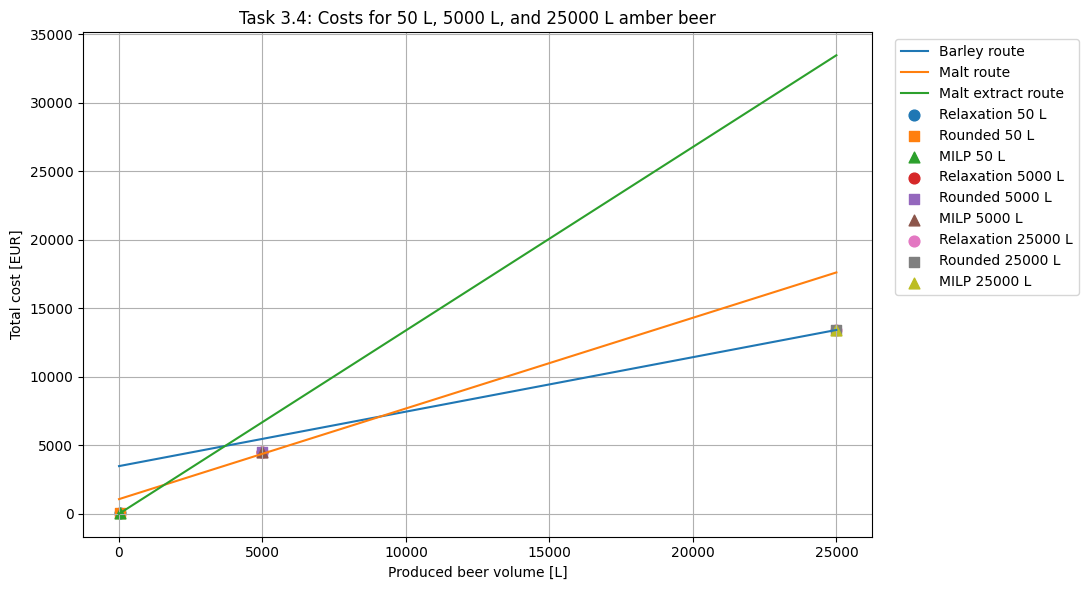

In [5]:
CHEAPEST_BARLEY_COST = cheapest_cost(barley)
CHEAPEST_MALT_COST = cheapest_cost(malts)
CHEAPEST_MALTEXTRACT_COST = cheapest_cost(maltextracts)
CHEAPEST_HOP_COST = cheapest_cost(hops)
CHEAPEST_YEAST_COST = cheapest_cost(yeasts)

MALTING_FIXED_COST = float(maltprocess.loc[0, "fixedcost"])
MALTING_VARIABLE_COST = float(maltprocess.loc[0, "variablecost"])
MASHING_FIXED_COST = float(mashingprocess.loc[0, "fixedcost"])
MASHING_VARIABLE_COST = float(mashingprocess.loc[0, "variablecost"])

def barley_route_cost(v_beer):
    m_eq = malt_extract_eq_needed_for_beer(v_beer)
    barley_kg = m_eq / BARLEY_TO_MALTEXTRACT_EQ
    malt_kg = malt_from_barley(barley_kg)
    return (
        barley_kg * CHEAPEST_BARLEY_COST
        + MALTING_FIXED_COST + MALTING_VARIABLE_COST * barley_kg
        + MASHING_FIXED_COST + MASHING_VARIABLE_COST * malt_kg
        + hops_needed_for_beer(v_beer) * CHEAPEST_HOP_COST
        + yeast_needed_for_beer(v_beer) * CHEAPEST_YEAST_COST
    )

def malt_route_cost(v_beer):
    m_eq = malt_extract_eq_needed_for_beer(v_beer)
    malt_kg = m_eq / MALT_TO_MALTEXTRACT_EQ
    return (
        malt_kg * CHEAPEST_MALT_COST
        + MASHING_FIXED_COST + MASHING_VARIABLE_COST * malt_kg
        + hops_needed_for_beer(v_beer) * CHEAPEST_HOP_COST
        + yeast_needed_for_beer(v_beer) * CHEAPEST_YEAST_COST
    )

def maltextract_route_cost(v_beer):
    m_eq = equivalent_maltextract_needed_for_beer(v_beer)
    return (
        m_eq * CHEAPEST_MALTEXTRACT_COST
        + hops_needed_for_beer(v_beer) * CHEAPEST_HOP_COST
        + yeast_needed_for_beer(v_beer) * CHEAPEST_YEAST_COST
    )

volumes = np.linspace(1, 25000, 400)
barley_costs = np.array([barley_route_cost(v) for v in volumes])
malt_costs = np.array([malt_route_cost(v) for v in volumes])
extract_costs = np.array([maltextract_route_cost(v) for v in volumes])

plt.figure(figsize=(11, 6))
plt.plot(volumes, barley_costs, label="Barley route")
plt.plot(volumes, malt_costs, label="Malt route")
plt.plot(volumes, extract_costs, label="Malt extract route")

for _, row in summary_df.iterrows():
    plt.scatter(row["V_beer"], row["relax_cost"], marker="o", s=60, label=f"Relaxation {int(row['V_beer'])} L")
    plt.scatter(row["V_beer"], row["rounded_cost"], marker="s", s=60, label=f"Rounded {int(row['V_beer'])} L")
    plt.scatter(row["V_beer"], row["milp_cost"], marker="^", s=60, label=f"MILP {int(row['V_beer'])} L")

plt.xlabel("Produced beer volume [L]")
plt.ylabel("Total cost [EUR]")
plt.title("Task 3.4: Costs for 50 L, 5000 L, and 25000 L amber beer")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 3.4.3 Cost per Litre

The last part of Task 3.4 asks how the cost per litre behaves. We compute this directly from the rounded and MILP costs and compare the three volumes.

In [6]:
summary_df["rounded_cost_per_litre"] = summary_df["rounded_cost"] / summary_df["V_beer"]
summary_df["milp_cost_per_litre"] = summary_df["milp_cost"] / summary_df["V_beer"]
summary_df[[
    "V_beer",
    "relax_cost",
    "rounded_cost",
    "milp_cost",
    "rounded_cost_per_litre",
    "milp_cost_per_litre",
]]

,V_beer,relax_cost,rounded_cost,milp_cost,rounded_cost_per_litre,milp_cost_per_litre
0,50,67.767155,67.767155,67.767155,1.355343,1.355343
1,5000,4497.686957,4497.686957,4497.686957,0.899537,0.899537
2,25000,13420.212719,13420.212719,13420.212719,0.536809,0.536809
